In [2]:
import os
import glob
import cv2
import torch
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score
import timm

# 1. Download HAM10000
path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
print("Dataset downloaded to:", path)

# 2. Find CSV file dynamically
csv_files = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)
# Ensure to load the HAM10000_metadata.csv for image IDs
metadata_csv_path = next((f for f in csv_files if 'metadata' in os.path.basename(f)), None)
if metadata_csv_path:
    df = pd.read_csv(metadata_csv_path)
else:
    raise FileNotFoundError("HAM10000_metadata.csv not found.")

# Ensure image_id exists regardless of capitalization
df.columns = df.columns.str.strip().str.lower()
if 'image_id' not in df.columns:
    # Fallback search for ID column
    id_col = [c for c in df.columns if 'id' in c][0]
    df.rename(columns={id_col: 'image_id'}, inplace=True)

# 3. Locate image file paths
all_image_paths = glob.glob(os.path.join(path, "**", "*.jpg"), recursive=True)
image_path_dict = {os.path.splitext(os.path.basename(x))[0]: x for x in all_image_paths}

df['path'] = df['image_id'].map(image_path_dict)
df = df.dropna(subset=['path']).reset_index(drop=True)

# 4. Map diagnosis codes to integers
label_mapping = {label: idx for idx, label in enumerate(df['dx'].unique())}
df['label'] = df['dx'].map(label_mapping)

print(f"\nTotal Valid Images: {len(df)}")
print("Class Map:", label_mapping)

# Stratified Split
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Dataset downloaded to: /kaggle/input/skin-cancer-mnist-ham10000

Total Valid Images: 10015
Class Map: {'bkl': 0, 'nv': 1, 'df': 2, 'mel': 3, 'vasc': 4, 'bcc': 5, 'akiec': 6}


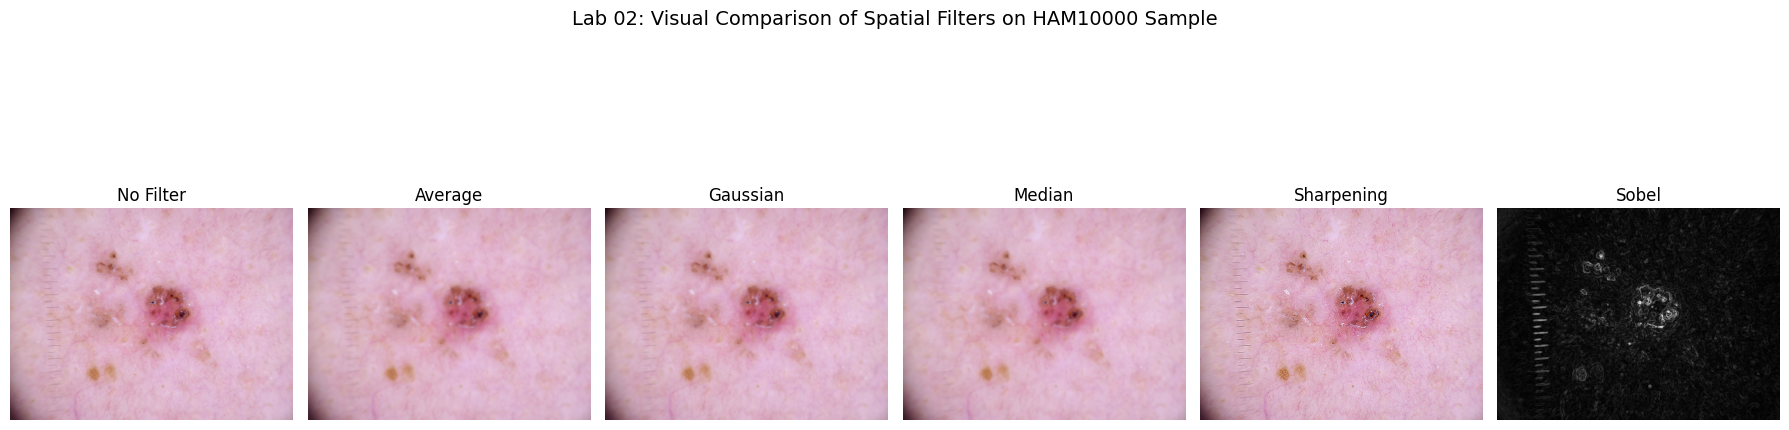

In [3]:
# Spatial Filter Implementations (Returns RGB NumPy arrays)
def apply_average_filter(img_np):
    return cv2.blur(img_np, (5, 5))

def apply_gaussian_filter(img_np):
    return cv2.GaussianBlur(img_np, (5, 5), 0)

def apply_median_filter(img_np):
    return cv2.medianBlur(img_np, 5)

def apply_sharpening_filter(img_np):
    kernel = np.array([[0, -1, 0],
                       [-1, 5, -1],
                       [0, -1, 0]])
    return cv2.filter2D(img_np, -1, kernel)

def apply_sobel_filter(img_np):
    gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
    sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    sobel = cv2.magnitude(sobelx, sobely)
    sobel = np.uint8(np.clip(sobel, 0, 255))
    return cv2.cvtColor(sobel, cv2.COLOR_GRAY2RGB)

FILTERS = {
    "No Filter": None,
    "Average": apply_average_filter,
    "Gaussian": apply_gaussian_filter,
    "Median": apply_median_filter,
    "Sharpening": apply_sharpening_filter,
    "Sobel": apply_sobel_filter
}

# --- Visual Inspection of Filters ---
sample_img_path = train_df.iloc[0]['path']
raw_img = Image.open(sample_img_path).convert('RGB')
raw_np = np.array(raw_img)

plt.figure(figsize=(18, 6))
for i, (f_name, f_func) in enumerate(FILTERS.items()):
    processed = f_func(raw_np.copy()) if f_func else raw_np

    plt.subplot(1, 6, i + 1)
    plt.imshow(processed)
    plt.title(f_name)
    plt.axis("off")

plt.suptitle("Lab 02: Visual Comparison of Spatial Filters on HAM10000 Sample", fontsize=14)
plt.tight_layout()
plt.show()

In [4]:
class FilteredHAMDataset(Dataset):
    def __init__(self, df, filter_func=None, transform=None):
        self.df = df.reset_index(drop=True)
        self.filter_func = filter_func
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, 'path']
        label = self.df.loc[idx, 'label']

        # Load raw image
        img = Image.open(img_path).convert('RGB')
        img_np = np.array(img)

        # Apply selected Spatial Filter
        if self.filter_func is not None:
            img_np = self.filter_func(img_np)

        img_pil = Image.fromarray(img_np)

        if self.transform:
            img_pil = self.transform(img_pil)

        return img_pil, label

# Standard ImageNet Transforms
tensor_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [5]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import pandas as pd
from tqdm.notebook import tqdm
from torchvision.models import (
    vgg16, VGG16_Weights,
    resnet18, ResNet18_Weights,
    efficientnet_b0, EfficientNet_B0_Weights
)
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score

# 1. Device Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running training on: {device}")

# 2. Model Loader Function (Native torchvision - loads instantly)
def get_model(model_name, num_classes):
    if model_name == 'vgg16':
        model = vgg16(weights=VGG16_Weights.DEFAULT)
        # Freeze features for fast fine-tuning
        for param in model.features.parameters():
            param.requires_grad = False
        model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)

    elif model_name == 'resnet18':
        model = resnet18(weights=ResNet18_Weights.DEFAULT)
        for param in model.parameters():
            param.requires_grad = False
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    elif model_name == 'efficientnet_b0':
        model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
        for param in model.features.parameters():
            param.requires_grad = False
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

    return model.to(device)

# 3. Experiment Configuration
models_to_test = ['vgg16', 'resnet18', 'efficientnet_b0']
num_classes = len(label_mapping)
num_epochs = 2  # Keep at 2-3 epochs for lab speed

all_lab2_results = []

# 4. Main Experiment Loop
for filter_name, filter_fn in FILTERS.items():
    print(f"\n=======================================================")
    print(f"       RUNNING EXPERIMENTS FOR FILTER: {filter_name.upper()}")
    print(f"=======================================================")

    # Create Filtered Datasets
    tr_dataset = FilteredHAMDataset(train_df, filter_func=filter_fn, transform=tensor_transform)
    te_dataset = FilteredHAMDataset(test_df, filter_func=filter_fn, transform=tensor_transform)

    tr_loader = DataLoader(tr_dataset, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
    te_loader = DataLoader(te_dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

    for model_name in models_to_test:
        print(f"\n--- Model: {model_name} | Filter: {filter_name} ---")
        model = get_model(model_name, num_classes)

        criterion = nn.CrossEntropyLoss()
        # Only optimize parameters that require gradients
        optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)

        # Training Phase
        model.train()
        for epoch in range(num_epochs):
            running_loss = 0.0
            pbar = tqdm(tr_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)

            for imgs, lbls in pbar:
                imgs, lbls = imgs.to(device), lbls.to(device)
                optimizer.zero_grad()
                outputs = model(imgs)
                loss = criterion(outputs, lbls)
                loss.backward()
                optimizer.step()

                running_loss += loss.item()
                pbar.set_postfix({'loss': f"{loss.item():.4f}"})

            print(f"Epoch [{epoch+1}/{num_epochs}] Avg Loss: {running_loss/len(tr_loader):.4f}")

        # Evaluation Phase
        model.eval()
        preds_list, labels_list, probs_list = [], [], []

        with torch.no_grad():
            for imgs, lbls in tqdm(te_loader, desc="Evaluating", leave=False):
                imgs = imgs.to(device)
                outputs = model(imgs)
                probs = torch.softmax(outputs, dim=1)
                preds = torch.argmax(probs, dim=1)

                preds_list.extend(preds.cpu().numpy())
                labels_list.extend(lbls.numpy())
                probs_list.extend(probs.cpu().numpy())

        # Calculate Required Metrics
        acc = accuracy_score(labels_list, preds_list) * 100
        prec, rec, f1, _ = precision_recall_fscore_support(labels_list, preds_list, average='macro', zero_division=0)

        try:
            auc = roc_auc_score(labels_list, probs_list, multi_class='ovr', average='macro') * 100
        except Exception:
            auc = 0.0

        all_lab2_results.append({
            "Model": model_name,
            "Filter": filter_name,
            "Accuracy (%)": f"{acc:.2f}",
            "Precision (%)": f"{prec*100:.2f}",
            "Recall (%)": f"{rec*100:.2f}",
            "Macro-F1 (%)": f"{f1*100:.2f}",
            "AUC (%)": f"{auc:.2f}"
        })

# 5. Final Display
lab2_summary_df = pd.DataFrame(all_lab2_results)
display(lab2_summary_df)

Running training on: cuda

       RUNNING EXPERIMENTS FOR FILTER: NO FILTER

--- Model: vgg16 | Filter: No Filter ---
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:05<00:00, 97.3MB/s]


Epoch 1/2:   0%|          | 0/126 [00:00<?, ?it/s]

Epoch [1/2] Avg Loss: 0.9853


Epoch 2/2:   0%|          | 0/126 [00:00<?, ?it/s]

...

Epoch [1/2] Avg Loss: 1.1013


Epoch 2/2:   0%|          | 0/126 [00:00<?, ?it/s]

Epoch [2/2] Avg Loss: 0.9294


Evaluating:   0%|          | 0/32 [00:00<?, ?it/s]

,Model,Filter,Accuracy (%),Precision (%),Recall (%),Macro-F1 (%),AUC (%)
0,vgg16,No Filter,74.14,56.49,34.97,38.77,90.13
1,resnet18,No Filter,72.94,53.22,36.25,38.00,90.90
2,efficientnet_b0,No Filter,74.49,48.61,40.95,43.59,90.19
3,vgg16,Average,77.68,52.59,47.06,49.02,90.93
4,resnet18,Average,72.84,53.58,34.37,35.83,89.82
5,efficientnet_b0,Average,75.69,56.57,39.99,44.12,89.52
6,vgg16,Gaussian,75.74,51.25,45.15,44.57,90.71
7,resnet18,Gaussian,73.84,57.04,31.96,35.52,90.60
8,efficientnet_b0,Gaussian,74.24,48.72,41.63,43.91,89.45
9,vgg16,Median,75.44,52.80,44.79,44.31,89.69
